In [9]:
# # collide2v_intro
# !pip install awkward

# # emg2pose_intro
# # !pip install -e emg2pose/
# !pip install h5py==3.11.0 hydra-core==1.3.2 omegaconf joblib==1.4.2 tqdm

In [2]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.optimizers.schedules import CosineDecay
from keras.callbacks import ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import load_model
from keras import Model
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#first some imports
import glob
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
# import torch
# import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

seed = 0
np.random.seed(seed)
# torch.manual_seed(seed)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

In [3]:
#load 3000 events per process
DATA_ROOT = Path("../../../hack-data/C1_HH4b/train")
N_EVENTS_PER_SAMPLE = 3000   # small subset per process -- bump this up once you trust the pipeline
N_PARTICLES_MAX = 16        # candidates kept per event (truncate/zero-pad), matches the original tutorial
CAND_FIELDS = ["pt", "eta", "phi", "dxy"]

SAMPLES = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
print("Samples found:", SAMPLES)

Samples found: ['HH_4b', 'QCD_HT250toInf', 'WJetsToLNu_13TeV-madgraphMLM-pythia8', 'WJetsToQQ_13TeV-madgraphMLM-pythia8', 'tt0123j_5f_ckm_LO_MLM_hadronic', 'tt0123j_5f_ckm_LO_MLM_leptonic', 'tt0123j_5f_ckm_LO_MLM_semiLeptonic']


In [4]:
# Read in just the first N events of a sample's first train fragment
def read_first_fragment(sample_dir: Path, n_events: int) -> ak.Array:
    frag = sorted(sample_dir.glob(f"{sample_dir.name}_*.parquet"))[0]
    pf = pq.ParquetFile(frag)
    batch = next(pf.iter_batches(batch_size=n_events, columns=["L1T_PUPPIPart", "label"]))
    return ak.from_arrow(batch)

# Reorganize the data into (N_events, N_particles, N_features) padded tensors (not variable length)
def load_physics_dataset_from_pvc(samples, n_events_per_sample=N_EVENTS_PER_SAMPLE,
                                   n_particles_max=N_PARTICLES_MAX, fields=CAND_FIELDS):
    X_parts, y_parts = [], []

    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        labels = ak.to_numpy(arr["label"])

        per_field = []
        for f in fields:
            padded = ak.pad_none(cands[f], n_particles_max, clip=True, axis=1)
            per_field.append(ak.to_numpy(ak.fill_none(padded, 0.0)).astype(np.float32))
        # each entry in per_field is (N_events, N_particles) -> stack into (N_events, N_particles, N_features)
        sample_X = np.stack(per_field, axis=-1)

        X_parts.append(sample_X)
        y_parts.append(labels)
        print(f"{sample}: loaded {len(arr)} events, label={labels[0]}")

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    return X, y


X, y = load_physics_dataset_from_pvc(SAMPLES)
print(X.shape, y.shape)  # (N_total_events, N_particles, N_features), (N_total_events,)
print("Class counts:", {int(c): int((y == c).sum()) for c in np.unique(y)})

HH_4b: loaded 3000 events, label=1
QCD_HT250toInf: loaded 3000 events, label=0
WJetsToLNu_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
WJetsToQQ_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
tt0123j_5f_ckm_LO_MLM_hadronic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_leptonic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_semiLeptonic: loaded 3000 events, label=2
(21000, 16, 4) (21000,)
Class counts: {0: 3000, 1: 3000, 2: 9000, 3: 6000}


In [5]:
# what is stored in the reconstructed particles `L1_PUPPIPart?
hh4b_frag = read_first_fragment(DATA_ROOT / "HH_4b", 1) #just one event
hh4b_frag["L1T_PUPPIPart"].fields 

['pt',
 'eta',
 'phi',
 'dxy',
 'dxysig',
 'pdgId',
 'charge',
 'pt_weighted',
 'puppi_weight',
 'e',
 'mass',
 'dz',
 'error_dz',
 'funique_id']

In [6]:
#preprocess and normalize etc the data
def preprocess_particles(X, pt_index=0, eta_index=1, phi_index=2, d0_index=3, eta_range=(-5.0, 5.0)):
    X_proc = X.copy()

    pt = X_proc[:, :, pt_index]
    pt_logged = np.log(pt + 1.0)
    pt_min, pt_max = pt_logged.min(), pt_logged.max()
    X_proc[:, :, pt_index] = (pt_logged - pt_min) / (pt_max - pt_min + 1e-8)

    eta_min, eta_max = eta_range
    X_proc[:, :, eta_index] = np.clip((X_proc[:, :, eta_index] - eta_min) / (eta_max - eta_min), 0.0, 1.0)

    d0 = X_proc[:, :, d0_index]
    d0_min, d0_max = d0.min(), d0.max()
    X_proc[:, :, d0_index] = (d0 - d0_min) / (d0_max - d0_min + 1e-8)

    phi = X_proc[:, :, phi_index]
    phi_cos, phi_sin = np.cos(phi), np.sin(phi)
    X_proc = np.delete(X_proc, phi_index, axis=2)
    X_proc = np.concatenate([X_proc, phi_cos[..., np.newaxis], phi_sin[..., np.newaxis]], axis=2)
    return X_proc


X_proc = preprocess_particles(X)
print(X_proc.shape)  # (N_events, N_particles, 5) -- pt, eta, dxy, cos(phi), sin(phi)

(21000, 16, 5)


In [18]:
# Transformer class

class TransformerBlock(layers.Layer):

    def __init__(self,embed_dim,num_heads,ff_dim,dropout=0.1,**kwargs):
        super().__init__(**kwargs)

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=None):

        attention_output = self.attention(x,x,training=training)

        x = self.norm1(
            x + self.dropout1(attention_output,training=training)
        )

        ffn_output = self.ffn(x,training=training)

        x = self.norm2(x + self.dropout2(ffn_output,training=training))

        return x

In [19]:
#define our train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.4, random_state=42, stratify=y, shuffle=True
)
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.2, random_state=42, stratify=y_test, shuffle=True
)
print("train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# X_train_t = torch.from_numpy(X_train).float()
# y_train_t = torch.from_numpy(y_train).long()
# X_val_t = torch.from_numpy(X_val).float()
# y_val_t = torch.from_numpy(y_val).long()
# X_test_t = torch.from_numpy(X_test).float()
# y_test_t = torch.from_numpy(y_test).long()
# n_classes = int(y.max()) + 1

train/val/test: 12600 1680 6720


In [20]:
teacher = load_model("../mlp_best_model.keras",     
                     custom_objects={"TransformerBlock": TransformerBlock})
teacher.summary()

/opt/conda/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_2', howev

Model: "functional_76"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_74 (InputLayer)     │ (None, 16, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 16, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_15 (Add)                    │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 16, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 16, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 16, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 16, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_193 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_286 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_194 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_287 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_195 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_288 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_196 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_289 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_197 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,610,733 (9.96 MB)

 Trainable params: 870,244 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,740,489 (6.64 MB)

In [21]:
retrain = False;
from keras.callbacks import ModelCheckpoint

checkpoint_path = "mlp_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

if retrain:
    initial_lr = 1e-3
    epochs = 20
    steps_per_epoch = X_train.shape[0] // 512
    lr_schedule = CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=epochs * steps_per_epoch,
        alpha=1e-4
    )
    
    optimizer = Adam(learning_rate=lr_schedule)

    mlp.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = mlp.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=64,  # The ratio of learning rate to batch size controls the “temperature” of the optimiser: higher values promote exploration. Temperature also affects the geometry of the minima. Paper: https://openreview.net/references/pdf?id=S1UD-XWCZ
        shuffle=True,
        callbacks=[checkpoint_cb]
    )
    
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"Final Train Accuracy: {trintermediate_layer_model = Model(
    inputs=model.input, outputs=model.get_layer('dense_1').output)
ain_acc:.3f}")
    print(f"Final Validation Accuracy: {val_acc:.3f}")
    print(f"Best model saved at: {checkpoint_path}")

SyntaxError: unterminated string literal (detected at line 41) (308649818.py, line 41)

In [32]:
from sklearn.metrics import accuracy_score
from keras.models import load_model
# teacher = mlp 
y_teacher = teacher.predict(np.ascontiguousarray(X_test))
y_test_out= y_test ==0
print('Accuracy quantized: {}'.format(accuracy_score(y_test, np.argmax(y_teacher, axis=1))))
# print(y_test)
# print(np.argmax(y_teacher,axis=1))

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy quantized: 0.65


In [33]:
learningLayer = "dense_196"
intermediate_layer_model = Model(
    inputs=teacher.input, outputs=teacher.get_layer(learningLayer).output)
intermediate_output_train = intermediate_layer_model.predict(X_train)
intermediate_output_val = intermediate_layer_model.predict(X_val)

373/394 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-09-04 05:45:33.676356: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_834', 8 bytes spill stores, 8 bytes spill loads

2026-09-04 05:45:34.007550: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30', 16 bytes spill stores, 16 bytes spill loads



394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step


In [34]:
print(intermediate_output_train)

[[ 0.36019996  0.17260306  0.57110953 ...  0.6002983  -0.1191662
  -0.16509132]
 [ 0.38375992  0.23628363  0.5640543  ...  0.59475666 -0.14275663
  -0.14683835]
 [ 0.35020974  0.18848601  0.30529693 ...  0.5004404  -0.10133356
  -0.16564518]
 ...
 [ 0.38994238  0.23477352  0.5045432  ...  0.6110046  -0.13871671
  -0.15982074]
 [ 0.38091832  0.21522637  0.45604676 ...  0.60128886 -0.12891494
  -0.16761975]
 [ 0.36235487  0.16521703  0.47487935 ...  0.58205545 -0.11481345
  -0.1695824 ]]


In [62]:

input_shape = X_train.shape[1:]
# n_classes = len(set(y_train))


initial_lr = 1e-3
epochs = 20
steps_per_epoch = X_train.shape[0] // 512
lr_schedule = CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=epochs * steps_per_epoch,
    alpha=1e-4
)

optimizer = Adam(learning_rate=lr_schedule)
optimizer = Adam()

inputs = layers.Input(shape=input_shape)
x = layers.Flatten()(inputs)


x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)

x = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.1)(x)

student= models.Model(inputs,x)
student.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)


In [63]:
history = student.fit(
    X_train, intermediate_output_train,
    validation_data=(X_val, intermediate_output_val),
    epochs=epochs,
    batch_size=64,  # The ratio of learning rate to batch size controls the “temperature” of the optimiser: higher values promote exploration. Temperature also affects the geometry of the minima. Paper: https://openreview.net/references/pdf?id=S1UD-XWCZ
    shuffle=True,
    callbacks=[]
)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.1631 - mae: 0.2322 - val_loss: 0.0756 - val_mae: 0.1503
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0876 - mae: 0.1622 - val_loss: 0.0600 - val_mae: 0.1365
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0743 - mae: 0.1514 - val_loss: 0.0428 - val_mae: 0.1315
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0588 - mae: 0.1419 - val_loss: 0.0373 - val_mae: 0.1247
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0557 - mae: 0.1385 - val_loss: 0.0371 - val_mae: 0.1252
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0538 - mae: 0.1368 - val_loss: 0.0341 - val_mae: 0.1221
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0526 - mae: 0.1360 - val_loss: 0.0311 - val_mae: 0.1185
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0511 - mae: 0.1342 - val_loss: 0.0300 - val_mae: 0.1174
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

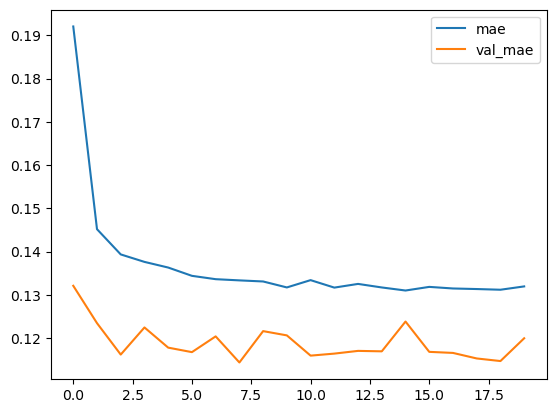

In [57]:
plt.plot(history.history["mae"],label="mae")
plt.plot(history.history["val_mae"],label="val_mae")
plt.legend()

In [58]:
#combine student with teacher
intermediate = teacher.get_layer(learningLayer)

teacher_head = tf.keras.Model(
    inputs=intermediate.output,
    outputs=teacher.output
)

student_input = student.input
student_32 = student.output

student_with_teacher_head = tf.keras.Model(
    inputs=student_input,
    outputs=teacher_head(student_32)
)

In [61]:
from sklearn.metrics import accuracy_score
from keras.models import load_model
y_student_with_teacher = student_with_teacher_head.predict(np.ascontiguousarray(X_test))
y_test_out= y_test !=0
print('Accuracy student: {}'.format(accuracy_score(y_test, np.argmax(y_student_with_teacher, axis=1))))

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step
Accuracy student: 0.6404761904761904


In [64]:
student_with_teacher_head.save("studentModel.keras")